<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Metodos-computacionales/Tarea2_MC_juanm_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

rad = np.pi/180

In [ ]:
# algunas funciones
def sen(x):
  return np.sin(x)

def cos(x):
  return np.cos(x)

In [ ]:
# METODO DE BISECCION para raices (con tolerancia)

def biseccion(f,a,b,tol): #funcion, intervalo(,), tolerancia

  if f(a)*f(b)>0:   #condicion antes de ejecucion del ciclo
    print('Error f(a) y f(b) deben tener signos contrarios')

  else:
    p= (a+b)/2 ; n=0 #punto medio y contador de iteraciones
    while np.abs(f(p)) > tol : #condicion iteracion(cuando el punto sea menor que la tolerancia para))

      if   f(a)*f(p) < 0:  b=p
      elif f(b)*f(p) < 0:  a=p

      p=(a+b)/2 #punto medio
      n+=1      #reinicio iterador
    #print('Raiz encontrada en ',n,' iteraciones')
    return p,n

#primero se llama a la funcion para los valores a evaluar: biseccion()
#si los puntos no cumplen la primer condicion salta el error. si si lo
#hacen entonces ya se pueden guardar los valores p,n=biseccion()

<br>

## **1. Utilizando el metodo de biseccion:**
<br>

Encontrar las raices de las siguientes funciones en el intervalo dado:

In [ ]:
#funciones
def f1(x):        # intervalo [-1,1] hay 2 raices
  return x**2-np.sin(x)

def f2(x):        # intervalo [1,2] hay 1 raiz
  return 3*x-np.exp(x)

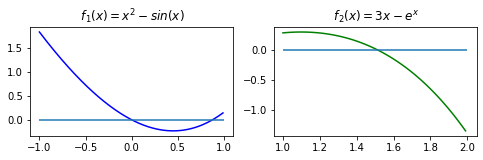

In [ ]:
#vista grafica de ambas funciones
x1=np.arange(-1, 1, 0.01); x2=np.arange(1, 2, 0.01)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,2))
axes[0].set_title(' $f_{1}(x)=x^{2}-sin(x)$ ')
axes[0].plot( x1, f1(x1), 'b')
axes[0].hlines(0, -1,1)
axes[1].set_title(' $f_{2}(x)=3x-e^{x}$ ')
axes[1].plot( x2, f2(x2), 'g')
axes[1].hlines(0, 1,2)

In [ ]:
biseccion(f1, -1, 1, 1e-8)
#para la funcion 1 seleccionando los extremos del intervalo no sirve, pues ambos
#evaluados en la funcion tienen el mismo signo, luego hay que dividir el intervalo

Error f(a) y f(b) deben tener signos contrarios


In [ ]:
# Funcion 1-----------------------------------------------
print('Para la funcion 1: x**2-sin(x)\n')
tole=1e-8 #tolerancia

# 1er intervalo
a=-1 ; b=0.5
raiz1= biseccion(f1, a, b, tole)
print(f'En el intervalo ({a},{b}) la raiz es {raiz1[0]} ')
# 2do intervalo
a=0.5 ; b=1
raiz2= biseccion(f1, a ,b, tole)
print(f'En el intervalo ({a},{b}) la raiz es {raiz2[0]}')
#---------------------------------------------------------

Para la funcion 1: x**2-sin(x)

En el intervalo (-1,0.5) la raiz es 7.450580596923828e-09 
En el intervalo (0.5,1) la raiz es 0.8767262101173401


In [ ]:
# Funcion 2-----------------------------------------------
print('Para la funcion 2: 3x-e**x\n')
tole=1e-8 #tolerancia

a=1 ; b=2
raiz3=biseccion(f2, a, b, tole)
print(f'En el intervalo ({a},{b}) la raiz es {raiz3[0]}')
#---------------------------------------------------------

Para la funcion 2: 3x-e**x

En el intervalo (1,2) la raiz es 1.5121345520019531


<br>

## **2. N-iteracion vs Tolerancia**
<br>

Modifique el programa de biseccion usado en el punto anterior, con el objetivo de hacer una grafica N-iter vs tolerancia. Pongalo a prueba con la raiz encontrada de la funcion $f_{2}(x) = 3x − e^{x}$, Analice y haga un breve comentario del resultado.

[0.1, 0.010000000000000002, 0.0010000000000000002, 0.00010000000000000003, 1.0000000000000004e-05, 1.0000000000000004e-06, 1.0000000000000005e-07, 1.0000000000000005e-08, 1.0000000000000005e-09, 1.0000000000000006e-10, 1.0000000000000006e-11, 1.0000000000000006e-12, 1.0000000000000007e-13, 1.0000000000000008e-14, 1.0000000000000009e-15, 1.000000000000001e-16, 1.000000000000001e-17, 1.000000000000001e-18, 1.000000000000001e-19, 1.0000000000000011e-20, 1.0000000000000012e-21, 1.0000000000000012e-22, 1.0000000000000013e-23, 1.0000000000000014e-24, 1.0000000000000014e-25]
[0, 5, 7, 12, 15, 17, 17, 17, 17, 32, 32, 38, 42, 45, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48]


Text(0, 0.5, 'Tolerancia')

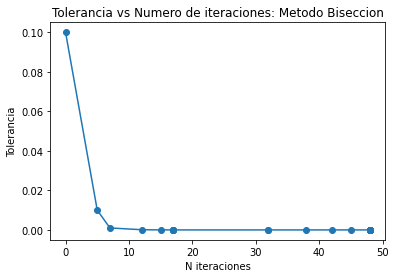

In [ ]:
list_iter =[]; tol_list=[]; to = 1e-1

for i in range(25):            # lista de tolerancias (1e-1, 1e-25)
  tol_list.append(to)
  to = to*1e-1

for i in range(len(tol_list)): # aplicando las tolerancias a la funcion bisecc.
  tol = tol_list[i]

  raiz, n_iter = biseccion(f2,1,2,tol)
  list_iter.append(n_iter)     # lista de iteraciones asociada a cada tolerancia

print(tol_list)
print(list_iter)

plt.plot( list_iter, tol_list,'o-')
plt.title('Tolerancia vs Numero de iteraciones: Metodo Biseccion')
plt.xlabel('N iteraciones')
plt.ylabel('Tolerancia')

####**Discusion:**

<p align="justify">  Se encontró que a medida que la tolerancia disminuye y aumenta la precision en la raiz, el numero de iteraciones aumenta, siguiendo una relacion inversa. Sin embargo, el numero de iteraciones se estabiliza en $48$ cuando la tolerancia disminuye de $1e^{-15}$; por debajo de esta, todas las tolerancias tienen el mismo numero de iteraciones. En general no siempre conviene tener una tolerancia tan baja, pues el numero de iteraciones se estabiliza y ademas, puede que se den errores de cancelacion sustractiva.
</p> <br>




## **3. Diferencia entre puntos fijos estables e inestables**
<br>

Definidos para el algoritmo de punto fijo:
*   Los puntos **fijos estables** son raices de una funcion $f(x)$ tales que dada una funcion $g(x)$, el algoritmo converge.
*   Por su parte los **puntos inestables** tambien son raices de la funcion $f(x)$, pero para los que la funcion $g(x)$ el algoritmo diverge.

<p align="justify"> En general estos puntos, sean estables o inestables, dependen completamente de la funcion $g(x)$ escogida. Como se mostrará acontinuacion para las raices de una funcion periodica como $f(x)=cos(x)$; si se toma una $g(x)$ particular, por ejemplo $g(x)=f(x)+x$ el metodo solo mostrará una familia de raices asociadas a esta $g(x)$ espaciadas por el periodo de la funcion; en este caso $2 \pi$. En realidad el algoritmo solo muestra una raiz, para encontrar el resto de raices se implementó un ciclo For que variara los puntos fijos iniciales.
Mientras que si se toma como segundo caso $g(x)=x-f(x)$, se podran encontrar las raices faltantes, que con respecto a la $g(x)$ del primer caso, serian los puntos inestables. </p> <br>



Por su parte, del libro de Burden, el teorema 2.4  Fixed-Point Theorem:

<p align="justify"> Si un punto que cumple con el algoritmo y ademas se tiene que la derivada de g(x) está definida en un intervalo especifico y que $|g'(x)|< k$, con un $k$ tal que $0 < k < 1$ entonces todo punto fijo en el intervalo converge a un unico valor, que cumple con las condiciones anteriores. En general se puede resumir el teorema para un punto fijo estable en estas tres condiciones: </p>

* Continuidad de g(x) en $[a,b]$ con $a< p_0< b$
* $a < g(p_0) < b$
* $|g'(p_0)|< 1$


### **Variando la funcion $g(x)$:**

In [ ]:
# Funcion punto fijo, y su variacion con cambio de la funcion g
def punto_fijo(f, p0, eps=1.0e-10,  Nmax=10000):
    def g(x):           # 1r forma de g(x)
      return f(x)+x
    i = 0               # contador de iteraciones
    while i<Nmax:
        i+=1
        p = g(p0)       # punto fijo entre a y b
        #print (i, p, np.abs(p - p0) )
        if (np.abs(p-p0) < eps): break # condición de parada
        p0 = p          #reinicio
    return p, i         # raiz, numero de iteraciones

def punto_fijo_2(f, p0, eps=1.0e-10,  Nmax=10000):
    def g(x):
      return x-f(x)     # cambio de g(x)
    i = 0
    while i<Nmax:
        i+=1
        p = g(p0)
        if (np.abs(p-p0) < eps): break
        p0 = p
    return p, i

raices estables: [1.5707963267948966, 1.5707963267948966, 1.5707963267948966, 1.5707963267948966, 1.5707963267948966, 7.853981633974483, 7.853981633974483, 7.853981633974483, 7.853981633974483, 7.853981633974483, 7.853981633974483, 14.137166941154069, 14.137166941154069, 14.137166941154069, 14.137166941154069, 14.137166941154069, 14.137166941154069, 14.137166941154069]
raices inestables [-1.5707963267948966, -1.5707963267948966, 4.71238898038469, 4.71238898038469, 4.71238898038469, 4.71238898038469, 4.71238898038469, 4.71238898038469, 10.995574287564276, 10.995574287564276, 10.995574287564276, 10.995574287564276, 10.995574287564276, 10.995574287564276, 10.995574287564276, 17.278759594743864, 17.278759594743864, 17.278759594743864] 



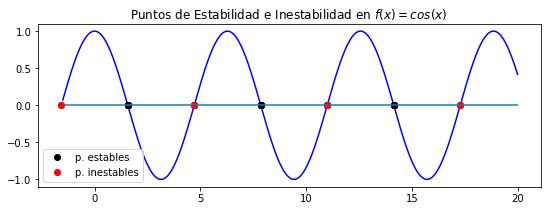

In [ ]:
R=[]; R2=[] # listas de las raices

for i in range(18):          #iteracion de pto fijo, con primer forma de g
  rai = punto_fijo (cos, i ) #i punto inicial
  R.append( rai[0] )           #añada cada raiz a la lista
print('raices estables:', R)

for i in range(18):          #iteracion de pto fijo, con segunda forma de g
  rai2 = punto_fijo_2( cos, i )
  R2.append( rai2[0] )       #[0] pues la raiz es el primer elemento arrojado
print('raices inestables',R2, '\n')


#grafica
x = np.arange(-1.5, 20, 0.01) # rango en x
plt.figure(figsize=(9,3))
plt.title('Puntos de Estabilidad e Inestabilidad en $f_{}(x)=cos(x)$ ')
plt.plot( x, cos(x), 'b')     #funcion cos(x)
plt.plot( R, np.zeros(len(R)), 'o', color='k', label='p. estables')
plt.plot( R2, np.zeros(len(R2)),'o', color='r', label='p. inestables')
plt.hlines(0, -1.5,20)        #linea horizontal en 0
plt.legend()

### **Con las derivadas de $g(x)$:**

Raiz 1, derivada de g(x) Y de g2(x) evaluadas en x=raiz
1.5707963267948966 0.0 2.0
1.5707963267948966 0.0 2.0
1.5707963267948966 0.0 2.0
1.5707963267948966 0.0 2.0

Raiz 2, derivada de g(x) Y de g2(x) evaluadas en x=raiz2
-1.5707963267948966 2.0 0.0
-1.5707963267948966 2.0 0.0
4.71238898038469 2.0 0.0
4.71238898038469 2.0 0.0


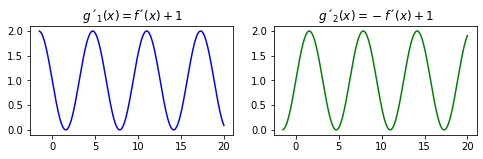

In [ ]:
def g_prim(x):
  return -np.sin(x)+1  #derivada de g1

def g_prim2(x):
  return np.sin(x)+1 #derivada de g2

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,2))
axes[0].set_title(' $g´_{1}(x)=f´(x)+1$ ')
axes[0].plot( x, g_prim(x) , 'b')
axes[1].set_title(' $g´_{2}(x)=-f´(x)+1$ ')
axes[1].plot( x, g_prim2(x) , 'g')

# Condicion de convergencia

print('Raiz 1, derivada de g(x) Y de g2(x) evaluadas en x=raiz')
for i in range(int( len(R)/4 )):
  print( R[i] , g_prim( R[i] ), g_prim2( R[i] ))    # evaluando la raiz=0 en la derivada de g1

print('\nRaiz 2, derivada de g(x) Y de g2(x) evaluadas en x=raiz2')
for i in range(int( len(R)/4 )):
  print( R2[i] , g_prim( R2[i] ), g_prim2( R2[i] ))    # evaluando la raiz=0 en la derivada de g1

# Note que la condicion |g'(x)|<=1 se cumple para las raices encontradas con la primer g(x),
# luego estos puntos son estables para esta g(x), ademas es inestable en las raices encontradas
# por por la segunda g2(x). Ahora si se toma como referencia g2(x) pasa lo contrario.
# por tanto se evidencia que la estabilidad de los puntos si depende de la g(x) elegida.

<br>

## **4. Raices de la funcion $f(x) = x^{2}cos(x)$ En el intervalo $[−2, 2]$ y clasificacion de sus puntos estables e inestables**
<br>

### **Solucion Analitica:**

$$ f(x_{0})=0=x^{2} \cos x $$
$$ \Rightarrow x=0 \vee  x=n\frac{\pi}{2}, n\in\mathbb{Z}- \left\{0\right\} $$

> Aplicando el intervalo:

$$ x \in \left[-2,2\right] \Rightarrow \left|x\right|= \left| n\frac{\pi}{2} \right| \leq 2 $$
$$ x = \left\{  -\frac{\pi}{2} ,0 , \frac{\pi}{2} \right\} $$
<br>

Ahora para la clasificacion de sus puntos fijos, se tienen los dos siguientes formas:
<br>


### **Con la Variacion de la funcion $g(x)$:**

<ipython-input-13-8915f7852c76>:2: RuntimeWarning: overflow encountered in double_scalars
  return (x**2)*np.cos(x)
<ipython-input-13-8915f7852c76>:2: RuntimeWarning: invalid value encountered in cos
  return (x**2)*np.cos(x)


raices estables: [0.0, 1.7378467282757093, 1.7378467282757093, nan, nan]
raices inestables [0.0, 9.990402603383366e-05, nan, nan, nan] 



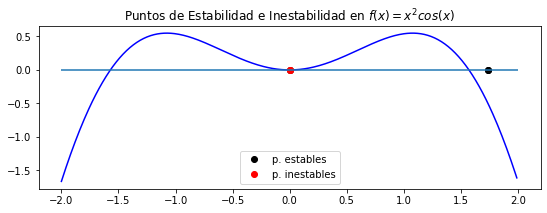

In [ ]:
def f(x):                # funcion a evaluar
  return (x**2)*np.cos(x)

R=[]; R2=[]              # listas de las raices

for i in range(5):       #iteracion de pto fijo, con primer forma de g ------
  rai = punto_fijo( f, i )
  R.append( rai[0] )
print('raices estables:', R)

for i in range(5):       #iteracion de pto fijo, con segunda forma de g -----
  rai2 = punto_fijo_2( f, i )
  R2.append( rai2[0] )
print('raices inestables',R2, '\n')


#grafica
x = np.arange(-2, 2, 0.01) # rango en x
plt.figure(figsize=(9,3))
plt.title('Puntos de Estabilidad e Inestabilidad en $f_{}(x)=x^{2}cos(x)$ ')
plt.plot( x, f(x), 'b')
plt.plot( R, np.zeros(len(R)), 'o', color='k', label='p. estables')
plt.plot( R2, np.zeros(len(R2)), 'o', color='r', label='p. inestables')
plt.hlines(0, -2,2)
plt.legend()
#solo la raiz x=0 coincide, el resto no corresponde, o diverge

### **Con las derivadas de $g(x)$:**

Raiz, derivada de g(x) y  g2(x) en x=raiz
-1.5707963267948966 3.4674011002723395 -1.4674011002723395
0 1.0 1.0
1.5707963267948966 -1.4674011002723395 3.4674011002723395


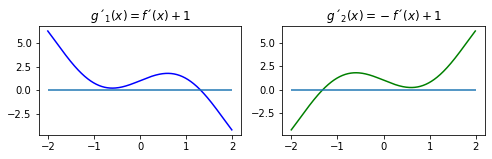

In [ ]:
def g_prim(x):
  return 2*x*np.cos(x)-x**2*np.sin(x)+1  #derivada de g1

def g_prim2(x):
  return -2*x*np.cos(x)+x**2*np.sin(x)+1 #derivada de g2

x = np.arange(-2, 2, 0.01)               # rango en x

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,2))
axes[0].set_title(' $g´_{1}(x)=f´(x)+1$ ')
axes[0].plot( x, g_prim(x) , 'b')
axes[0].hlines(0, -2,2)
axes[1].set_title(' $g´_{2}(x)=-f´(x)+1$ ')
axes[1].plot( x, g_prim2(x) , 'g')
axes[1].hlines(0, -2,2)


# Condicion de convergencia
raiz_real=[-np.pi/2 , 0 , np.pi/2]
print('Raiz, derivada de g(x) y  g2(x) en x=raiz')
for i in range(len(raiz_real)):
  print( raiz_real[i] , g_prim( raiz_real[i] ), g_prim2( raiz_real[i] ) )

# note que g'2 no es mas que -g'1
# El unico punto que cumple con la condicion |g'(x)|<=1 es x=0, luego este es
# el unico punto Estable. En el resto |g(x)|>1 luego son inestables

In [ ]:
#Tarea 2: 100/100
#1)20/20
#  a) 10/10
#  b) 10/10

#2)20/20
#  Niter vs Tol 20/20

#3)20/20
#  Puntos fijos 20/20

#4)20/20
#  Puntos fijos [-pi/2, 0, pi/2] 10/10
#  Clasificación 10/10

#5)20/20
#  Estables 20/20
